In [2]:
import os
import torch
import platform

print('Python platform:', platform.platform())
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA version:', torch.version.cuda)
else:
    print('GPU не обнаружен. Для обучения LoRA нужен GPU.')

Python platform: Linux-6.6.113+-x86_64-with-glibc2.35
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [3]:
BASE_MODEL = 'stabilityai/stable-diffusion-xl-base-1.0'
GENDER = 'man'
TRIGGER_TOKEN = 'bibaiboba'

RAW_IMAGES_DIR = './photos_raw'
TRAIN_DATA_DIR = './train_data'
OUTPUT_DIR = './lora_output'
GEN_DIR = './generated'

RESOLUTION = 768
MAX_TRAIN_STEPS = 400
CHECKPOINTING_STEPS = 100
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-4
RANK = 16
SEED = 42

os.makedirs(TRAIN_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(GEN_DIR, exist_ok=True)

print('BASE_MODEL =', BASE_MODEL)
print('RESOLUTION =', RESOLUTION)
print('MAX_TRAIN_STEPS =', MAX_TRAIN_STEPS)
print('RAW_IMAGES_DIR =', os.path.abspath(RAW_IMAGES_DIR))

BASE_MODEL = stabilityai/stable-diffusion-xl-base-1.0
RESOLUTION = 768
MAX_TRAIN_STEPS = 400
RAW_IMAGES_DIR = /content/photos_raw


In [ ]:
import json
from pathlib import Path
import numpy as np
import cv2
import pillow_heif
from PIL import Image, ImageFile, UnidentifiedImageError

ImageFile.LOAD_TRUNCATED_IMAGES = True
pillow_heif.register_heif_opener()

src_dir = Path(RAW_IMAGES_DIR)
img_dir = Path(TRAIN_DATA_DIR)
img_dir.mkdir(parents=True, exist_ok=True)

files = src_dir.rglob("*.jpeg")
files = sorted(files)

if len(files) < 8:
    raise ValueError(f'Найдено только {len(files)} файлов в {src_dir}')

def center_crop_resize(im: Image.Image, size: int) -> Image.Image:
    w, h = im.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    im = im.crop((left, top, left + side, top + side))
    return im.resize((size, size), Image.Resampling.LANCZOS)

def safe_open_rgb(path: Path) -> Image.Image:
    try:
        with Image.open(path) as im:
            return im.convert('RGB')
    except Exception:
        pass

    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        raise ValueError('empty file (0 bytes)')
    bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if bgr is None:
        raise UnidentifiedImageError(f'cannot decode: {path}')
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

metadata_path = img_dir / 'metadata.jsonl'
caption = f'{TRIGGER_TOKEN} {GENDER}, portrait photo, high quality, realism'

ok = 0
skipped = []
for old in img_dir.glob('*.jpg'):
    old.unlink()

with metadata_path.open('w', encoding='utf-8') as f:
    for p in files:
        try:
            im = safe_open_rgb(p)
            im = center_crop_resize(im, RESOLUTION)
            out_name = f'{ok:04d}.jpg'
            im.save(img_dir / out_name, quality=95)
            f.write(json.dumps({'file_name': out_name, 'text': caption}, ensure_ascii=False) + '\n')
            ok += 1
        except Exception as e:
            size = p.stat().st_size if p.exists() else -1
            skipped.append((str(p), size, str(e)))

print('Каталог train_data:', img_dir.resolve())
print('metadata:', metadata_path.resolve())

Каталог train_data: /content/train_data
metadata: /content/train_data/metadata.jsonl


In [ ]:
import os
import sys
import importlib

if not torch.cuda.is_available():
    raise RuntimeError('Нужен GPU runtime (Runtime -> Change runtime type -> GPU).')

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

repo_root = os.path.abspath('diffusers')
src_path = os.path.join(repo_root, 'src')
examples_path = os.path.join(repo_root, 'examples', 'text_to_image')

for p in [src_path, examples_path]:
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

for m in list(sys.modules.keys()):
    if m == 'diffusers' or m.startswith('diffusers.'):
        del sys.modules[m]

import diffusers
print('diffusers imported from:', getattr(diffusers, '__file__', 'unknown'))

train_mod = importlib.import_module('train_text_to_image_lora_sdxl')
parse_args, main = train_mod.parse_args, train_mod.main

args = parse_args([
    f'--pretrained_model_name_or_path={BASE_MODEL}',
    f'--train_data_dir={TRAIN_DATA_DIR}',
    '--caption_column=text',
    f'--resolution={RESOLUTION}',
    '--center_crop',
    f'--train_batch_size={TRAIN_BATCH_SIZE}',
    f'--gradient_accumulation_steps={GRADIENT_ACCUMULATION_STEPS}',
    f'--max_train_steps={MAX_TRAIN_STEPS}',
    f'--learning_rate={LEARNING_RATE}',
    '--lr_scheduler=constant',
    '--lr_warmup_steps=0',
    '--mixed_precision=fp16',
    '--gradient_checkpointing',
    '--dataloader_num_workers=2',
    f'--checkpointing_steps={CHECKPOINTING_STEPS}',
    f'--rank={RANK}',
    f'--seed={SEED}',
    f'--output_dir={OUTPUT_DIR}',
])

main(args)

diffusers imported from: /content/diffusers/src/diffusers/__init__.py


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
You are using a model of typ

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Steps:   0%|          | 0/400 [00:00<?, ?it/s]

Model weights saved in lora_output/checkpoint-100/pytorch_lora_weights.safetensors
Model weights saved in lora_output/checkpoint-200/pytorch_lora_weights.safetensors
Model weights saved in lora_output/checkpoint-300/pytorch_lora_weights.safetensors
Model weights saved in lora_output/checkpoint-400/pytorch_lora_weights.safetensors
Model weights saved in lora_output/pytorch_lora_weights.safetensors
{'feature_extractor', 'image_encoder'} was not found in config. Values will be initialized to default values.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loaded tokenizer_2 as CLIPTokenizer from `tokenizer_2` subfolder of stabilityai/stable-diffusion-xl-base-1.0.
Instantiating UNet2DConditionModel model under default dtype torch.float16.
{'attention_type', 'dropout', 'reverse_transformer_layers_per_block'} was not found in config. Values will be initialized to default values.
All model checkpoint weights were used when initializing UNet2DConditionModel.

All the weights of UNet2DConditionModel were initialized from the model checkpoint at /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/unet.
If your task is similar to the task the model of the checkpoint was trained on, you can already use UNet2DConditionModel for predictions without further training.
Loaded unet as UNet2DConditionModel from `unet` subfolder of stabilityai/stable-diffusion-xl-base-1.0.
Loaded tokenizer as CLIPTokenizer from `tokenizer` subfolder of stabilityai/stable-diffusion-xl-base-1.0.

In [ ]:
import torch
from diffusers import AutoPipelineForText2Image


pipe = AutoPipelineForText2Image.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    variant='fp16',
    use_safetensors=True
)
pipe.load_lora_weights(OUTPUT_DIR)
pipe = pipe.to('cuda')

lora_scale = 1.0
prompts = [
    f'{TRIGGER_TOKEN} {GENDER}, cinematic portrait, ultra detailed skin, natural light, high quality, realism',
    f'{TRIGGER_TOKEN} {GENDER} in a forest, high quality, realism',
    f'{TRIGGER_TOKEN} {GENDER} in a city, high quality, realism',
    f'{TRIGGER_TOKEN} {GENDER} in a beach, high quality, realism',
    f'{TRIGGER_TOKEN} {GENDER}, cyberpunk neon megacity at night, cinematic lighting, high quality, realism',
    f'{TRIGGER_TOKEN} {GENDER}, metallic body style, chrome texture, studio light, high quality, realism',
]

generator = torch.Generator(device='cuda').manual_seed(SEED)
saved = []
for i, prompt in enumerate(prompts, start=1):
    image = pipe(
        prompt=prompt,
        height=512,
        width=512,
        num_inference_steps=35,
        guidance_scale=6.0,
        cross_attention_kwargs={'scale': lora_scale},
        generator=generator
    ).images[0]
    out_path = os.path.join(GEN_DIR, f'{i:02d}.png')
    image.save(out_path)
    saved.append((out_path, prompt))

{'feature_extractor', 'image_encoder'} was not found in config. Values will be initialized to default values.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loaded tokenizer_2 as CLIPTokenizer from `tokenizer_2` subfolder of stabilityai/stable-diffusion-xl-base-1.0.
Instantiating AutoencoderKL model under default dtype torch.float16.
{'shift_factor', 'use_post_quant_conv', 'latents_std', 'mid_block_add_attention', 'latents_mean', 'use_quant_conv'} was not found in config. Values will be initialized to default values.
All model checkpoint weights were used when initializing AutoencoderKL.

All the weights of AutoencoderKL were initialized from the model checkpoint at /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/vae.
If your task is similar to the task the model of the checkpoint was trained on, you can already use AutoencoderKL for predictions without further training.
Loaded vae as AutoencoderKL from `vae` subfolder of stabilityai/stable-diffusion-xl-base-1.0.
Instantiating UNet2DConditionModel model under default dtype torch.float16.
{'attention_type', 'd

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

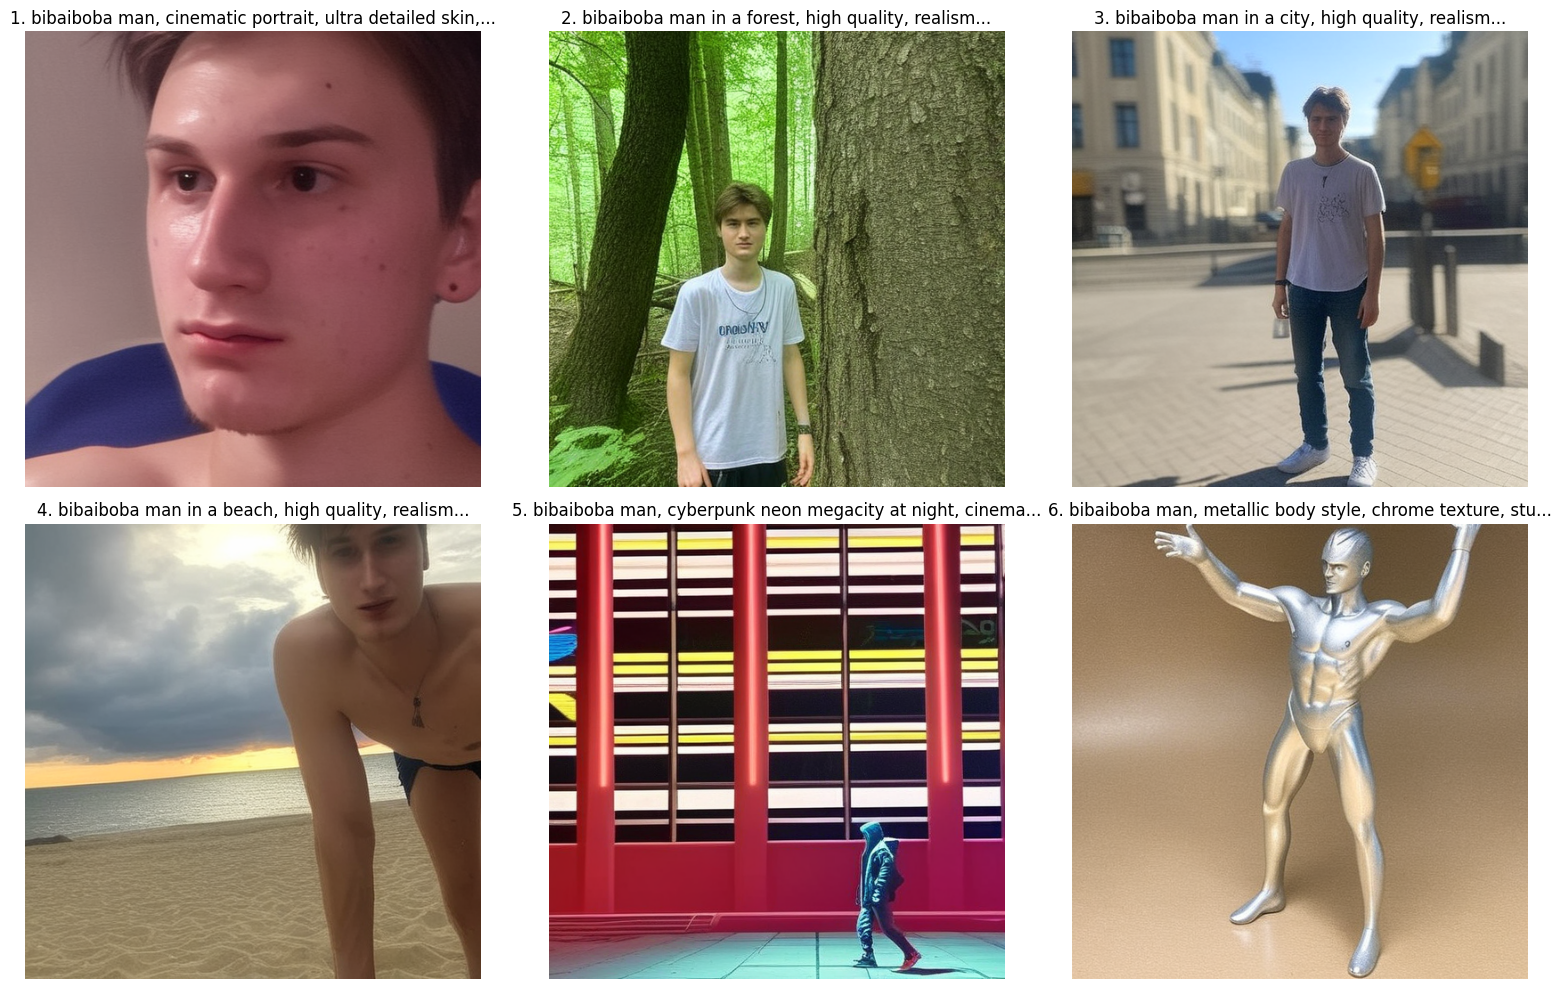

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (path, prompt) in enumerate(saved):
    axes[idx].imshow(Image.open(path))
    axes[idx].set_title(f'{idx+1}. {prompt[:55]}...')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()